<a href="https://colab.research.google.com/github/bangaru01/C_programing/blob/main/superimposed_by_stereo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== RS superimposed ===
  red        -> RS_CH2-Ph.xyz
  blue       -> RS_CH2-dioxane.xyz
  green      -> RS_CH2CN.xyz
  orange     -> RS_CH2CO2Me.xyz
  purple     -> RS_CMe2CO2Me.xyz
  cyan       -> RS_Cy.xyz
  magenta    -> RS_Et.xyz
  gold       -> RS_Me-Propane.xyz
  teal       -> RS_Me.xyz
  brown      -> RS_Ph.xyz
  pink       -> RS_alkene.xyz
  lime       -> RS_alkyne.xyz
  navy       -> RS_allyl.xyz
  maroon     -> RS_dimethyl-allyl.xyz
  olive      -> RS_iPr.xyz
  coral      -> RS_nBu.xyz
  indigo     -> RS_tBu.xyz


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/RS_superimposed.png  (attempt 1)
Computing pairwise RMSD matrix for RR group...
                       RR_CH2-Ph.xyz  RR_CH2-dioxane.xyz  RR_CH2CN.xyz  \
RR_CH2-Ph.xyz                  0.000               0.094         0.055   
RR_CH2-dioxane.xyz             0.094               0.000         0.056   
RR_CH2CN.xyz                   0.055               0.056         0.000   
RR_CH2CO2Me.xyz                0.085               0.108         0.083   
RR_CMe2CO2Me.xyz               0.063               0.099         0.068   
RR_Cy.xyz                      0.124               0.051         0.086   
RR_Et.xyz                      0.091               0.021         0.051   
RR_Me-Propane.xyz              0.107               0.094         0.096   
RR_Me.xyz                      0.074               0.115         0.088   
RR_Ph.xyz                      0.072               0.103         0.076   
RR_alkene.xyz                  0.072     

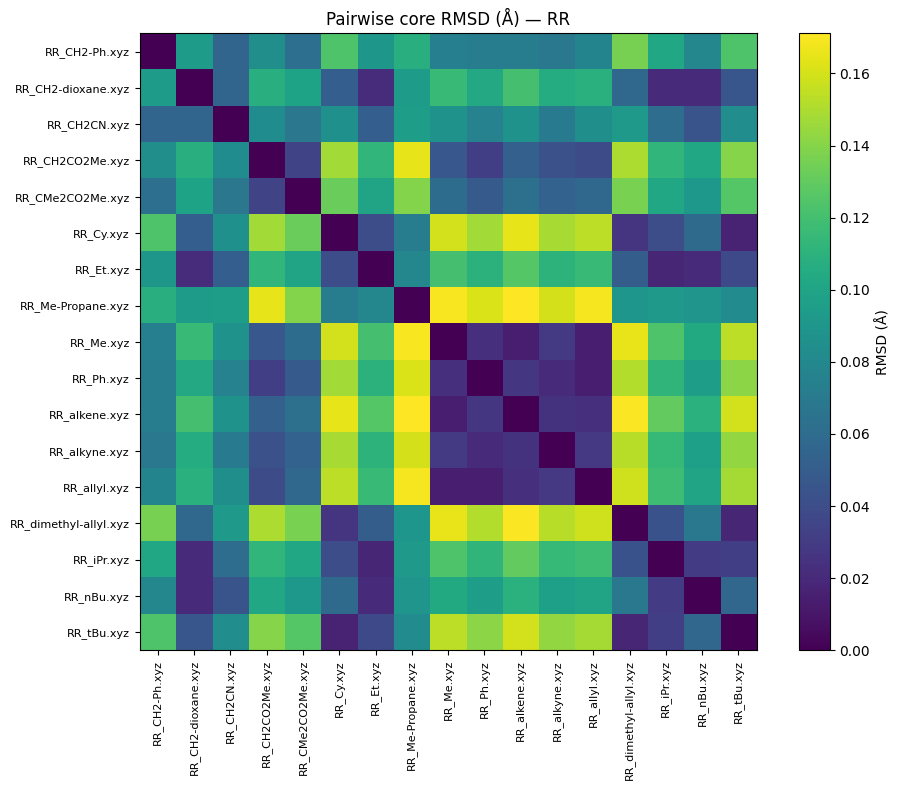

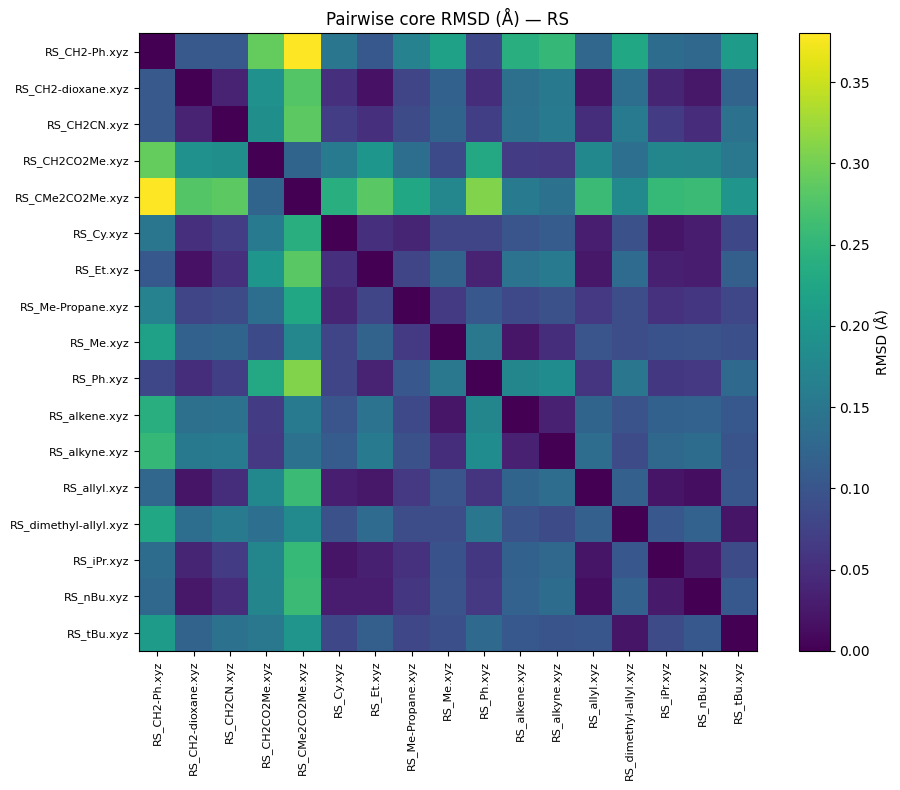

In [12]:
# ============================================================
# GOOGLE DRIVE
# ============================================================
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# ============================================================
# IMPORTS
# ============================================================
import os
import glob
import numpy as np

!pip install py3Dmol -q

# ============================================================
# 1. XYZ I/O HELPERS
# ============================================================
def read_xyz(path):
    with open(path) as f:
        lines = f.readlines()
    n_atoms = int(lines[0].strip())
    symbols, coords = [], []
    for line in lines[2:2 + n_atoms]:
        parts = line.split()
        symbols.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    return symbols, np.array(coords)

def write_xyz(path, symbols, coords, comment=""):
    with open(path, "w") as f:
        f.write(f"{len(symbols)}\n{comment}\n")
        for s, (x, y, z) in zip(symbols, coords):
            f.write(f"{s:<3} {x:>12.6f} {y:>12.6f} {z:>12.6f}\n")

# ============================================================
# 2. KABSCH ALIGNMENT (rigid-body fit on shared core atoms)
# ============================================================
def kabsch_align(mobile, target):
    mobile_c = mobile - mobile.mean(axis=0)
    target_c = target - target.mean(axis=0)
    H = mobile_c.T @ target_c
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1, 1, d])
    R = Vt.T @ D @ U.T
    t = target.mean(axis=0) - R @ mobile.mean(axis=0)
    rmsd = np.sqrt(np.mean(np.sum((mobile @ R.T + t - target) ** 2, axis=1)))
    return R, t, rmsd

# ============================================================
# 3. CONFIG
# ============================================================
xyz_folder = "/content/drive/MyDrive/xyz_files"

# Atoms 1-43 are the fixed common core (DDQ-H 1-15 + substrate C2-C18);
# atom 44 onward = R3, which varies in identity/size between files.
CORE_ATOMS_1INDEXED = list(range(1, 44))
core_idx = [i - 1 for i in CORE_ATOMS_1INDEXED]

# ============================================================
# 4. GROUP FILES BY PREFIX (RR_ vs RS_)
# ============================================================
all_files = sorted(glob.glob(os.path.join(xyz_folder, "*.xyz")))
print(f"Found {len(all_files)} XYZ files")

groups = {
    "RR": [f for f in all_files if os.path.basename(f).startswith("RR_")],
    "RS": [f for f in all_files if os.path.basename(f).startswith("RS_")],
}

for k, v in groups.items():
    print(f"  {k}: {len(v)} files")

leftover = [f for f in all_files if not (os.path.basename(f).startswith("RR_") or os.path.basename(f).startswith("RS_"))]
if leftover:
    print(f"⚠️ Files not matching RR_/RS_ prefix (ignored): {[os.path.basename(f) for f in leftover]}")

# ============================================================
# 5. SUPERIMPOSE EACH GROUP SEPARATELY
# ============================================================
def superimpose_group(file_list, group_name, out_root):
    if len(file_list) < 2:
        print(f"Skipping {group_name}: fewer than 2 structures ({len(file_list)})")
        return None
    out_dir = os.path.join(out_root, group_name)
    os.makedirs(out_dir, exist_ok=True)

    structs = []
    for f in file_list:
        symbols, coords = read_xyz(f)
        if max(core_idx) >= len(symbols):
            print(f"⚠️ {os.path.basename(f)}: only {len(symbols)} atoms, core range invalid — skipping")
            continue
        structs.append({"name": os.path.basename(f), "symbols": symbols, "coords": coords})

    ref = structs[0]
    ref_core = ref["coords"][core_idx]
    print(f"\n[{group_name}] Reference: {ref['name']}")

    for s in structs:
        mobile_core = s["coords"][core_idx]
        R, t, rmsd = kabsch_align(mobile_core, ref_core)
        s["coords_aligned"] = s["coords"] @ R.T + t   # apply to ALL atoms, incl. R3
        print(f"  {s['name']:32s} core RMSD = {rmsd:.4f} Å  (n_atoms={len(s['symbols'])})")
        write_xyz(os.path.join(out_dir, s["name"]), s["symbols"], s["coords_aligned"],
                  comment=f"{group_name}, aligned to {ref['name']}")

    combined = os.path.join(out_dir, f"all_{group_name}.xyz")
    with open(combined, "w") as f:
        for s in structs:
            f.write(f"{len(s['symbols'])}\n{s['name']}\n")
            for sym, (x, y, z) in zip(s["symbols"], s["coords_aligned"]):
                f.write(f"{sym:<3} {x:>12.6f} {y:>12.6f} {z:>12.6f}\n")
    print(f"  -> combined file: {combined}")
    return combined

out_root = os.path.join(xyz_folder, "superimposed_by_stereo")
combined_RR = superimpose_group(groups["RR"], "RR", out_root)
combined_RS = superimpose_group(groups["RS"], "RS", out_root)

# ============================================================
# 6. VISUALIZE EACH GROUP — COLORED BY R3 + SAVE DIRECTLY TO DRIVE
# ============================================================
# !pip install py3Dmol -q

from google.colab import output
from IPython.display import display, clear_output
import base64
import os
import time
import py3Dmol

COLOR_PALETTE = [
    "red", "blue", "green", "orange", "purple", "cyan", "magenta",
    "gold", "teal", "brown", "pink", "lime", "navy", "maroon",
    "olive", "coral", "indigo", "salmon", "turquoise", "orchid",
]

def render_group(combined_path, title):
    if combined_path is None or not os.path.exists(combined_path):
        print(f"No combined file for {title}")
        return None
    with open(combined_path) as f:
        block = f.read()
    lines = block.splitlines()
    view = py3Dmol.view(width=900, height=700)
    model_idx = 0
    i = 0
    legend = []
    while i < len(lines):
        n = int(lines[i].strip())
        frame_name = lines[i + 1].strip()
        frame = "\n".join(lines[i:i + n + 2])
        view.addModel(frame, "xyz")
        color = COLOR_PALETTE[model_idx % len(COLOR_PALETTE)]
        view.setStyle({"model": model_idx}, {"stick": {"color": color, "radius": 0.15}})
        legend.append((frame_name, color))
        model_idx += 1
        i += n + 2
    view.zoomTo()
    print(f"=== {title} ===")
    for name, color in legend:
        print(f"  {color:10s} -> {name}")
    view.show()
    return view


def capture_canvas_to_drive(filename, out_dir, wait_sec=3.0, retries=4):
    """Capture the most recently rendered canvas, retrying if it's not ready yet."""
    os.makedirs(out_dir, exist_ok=True)
    filepath = os.path.join(out_dir, filename)

    js_code = '''
    (function() {
        var canvases = document.querySelectorAll("canvas");
        if (canvases.length === 0) { return null; }
        var canvas = canvases[canvases.length - 1];
        try {
            return canvas.toDataURL("image/png");
        } catch(e) {
            return null;
        }
    })()
    '''

    for attempt in range(1, retries + 1):
        time.sleep(wait_sec)
        data_url = output.eval_js(js_code)
        if data_url is not None:
            encoded = data_url.split(",", 1)[1]
            with open(filepath, "wb") as f:
                f.write(base64.b64decode(encoded))
            print(f"✅ Saved: {filepath}  (attempt {attempt})")
            return True
        print(f"⏳ Attempt {attempt}/{retries}: canvas not ready yet for {filename}, retrying...")

    print(f"⚠️ Failed to capture {filename} after {retries} attempts.")
    return False


# ------------------------------------------------------------
# RR GROUP
# ------------------------------------------------------------
clear_output(wait=True)
rr_view = render_group(combined_RR, "RR superimposed")
capture_canvas_to_drive("RR_superimposed.png", out_root)

# ------------------------------------------------------------
# RS GROUP
# ------------------------------------------------------------
clear_output(wait=True)
rs_view = render_group(combined_RS, "RS superimposed")
capture_canvas_to_drive("RS_superimposed.png", out_root)


# ============================================================
# 7. RMSD CALCULATIONS (core atoms 1-43, since R3 varies in size)
# ============================================================
import pandas as pd

def compute_rmsd(coords_a, coords_b):
    """RMSD between two already-aligned coordinate sets of equal shape."""
    return np.sqrt(np.mean(np.sum((coords_a - coords_b) ** 2, axis=1)))

def load_core_coords(file_list, core_idx):
    """Load core-atom coordinates for a list of xyz files, keyed by filename."""
    data = {}
    for f in file_list:
        symbols, coords = read_xyz(f)
        if max(core_idx) >= len(symbols):
            print(f"⚠️ Skipping {os.path.basename(f)}: not enough atoms")
            continue
        data[os.path.basename(f)] = coords[core_idx]
    return data

def pairwise_rmsd_matrix(file_list, core_idx):
    """
    For every pair, Kabsch-align structure i onto structure j (core atoms only)
    and report the resulting RMSD. Diagonal = 0.
    """
    core_data = load_core_coords(file_list, core_idx)
    names = list(core_data.keys())
    n = len(names)
    mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            _, _, rmsd = kabsch_align(core_data[names[i]], core_data[names[j]])
            mat[i, j] = rmsd

    df = pd.DataFrame(mat, index=names, columns=names)
    return df

# ---- RR group ----
print("Computing pairwise RMSD matrix for RR group...")
rmsd_RR = pairwise_rmsd_matrix(groups["RR"], core_idx)
rmsd_RR.to_csv(os.path.join(out_root, "RR_pairwise_rmsd.csv"))
print(rmsd_RR.round(3))

# ---- RS group ----
print("\nComputing pairwise RMSD matrix for RS group...")
rmsd_RS = pairwise_rmsd_matrix(groups["RS"], core_idx)
rmsd_RS.to_csv(os.path.join(out_root, "RS_pairwise_rmsd.csv"))
print(rmsd_RS.round(3))

# ============================================================
# 8. RMSD SUMMARY STATS (max/mean deviation per group — quick sanity check)
# ============================================================
def summarize_rmsd(df, group_name):
    vals = df.values[np.triu_indices(len(df), k=1)]  # upper triangle, excl. diagonal
    print(f"\n[{group_name}] Pairwise RMSD (core, {len(df)} structures, {len(vals)} pairs):")
    print(f"  mean = {vals.mean():.4f} Å")
    print(f"  min  = {vals.min():.4f} Å")
    print(f"  max  = {vals.max():.4f} Å")

summarize_rmsd(rmsd_RR, "RR")
summarize_rmsd(rmsd_RS, "RS")

# ============================================================
# 9. (OPTIONAL) HEATMAP VISUALIZATION OF PAIRWISE RMSD
# ============================================================
import matplotlib.pyplot as plt

def plot_rmsd_heatmap(df, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(df.values, cmap="viridis")
    ax.set_xticks(range(len(df)))
    ax.set_yticks(range(len(df)))
    ax.set_xticklabels(df.columns, rotation=90, fontsize=8)
    ax.set_yticklabels(df.index, fontsize=8)
    ax.set_title(f"Pairwise core RMSD (Å) — {title}")
    fig.colorbar(im, ax=ax, label="RMSD (Å)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_root, f"{title}_rmsd_heatmap.png"), dpi=200)
    plt.show()

plot_rmsd_heatmap(rmsd_RR, "RR")
plot_rmsd_heatmap(rmsd_RS, "RS")

Files in: /content/drive/MyDrive/xyz_files/superimposed_by_stereo
  RR                                       4.0 KB
  RR_pairwise_rmsd.csv                     5.8 KB
  RR_rmsd_heatmap.png                    151.4 KB
  RR_superimposed.png                    524.1 KB
  RS                                       4.0 KB
  RS_pairwise_rmsd.csv                     5.8 KB
  RS_rmsd_heatmap.png                    155.5 KB
  RS_superimposed.png                    602.8 KB
RR_superimposed.png:


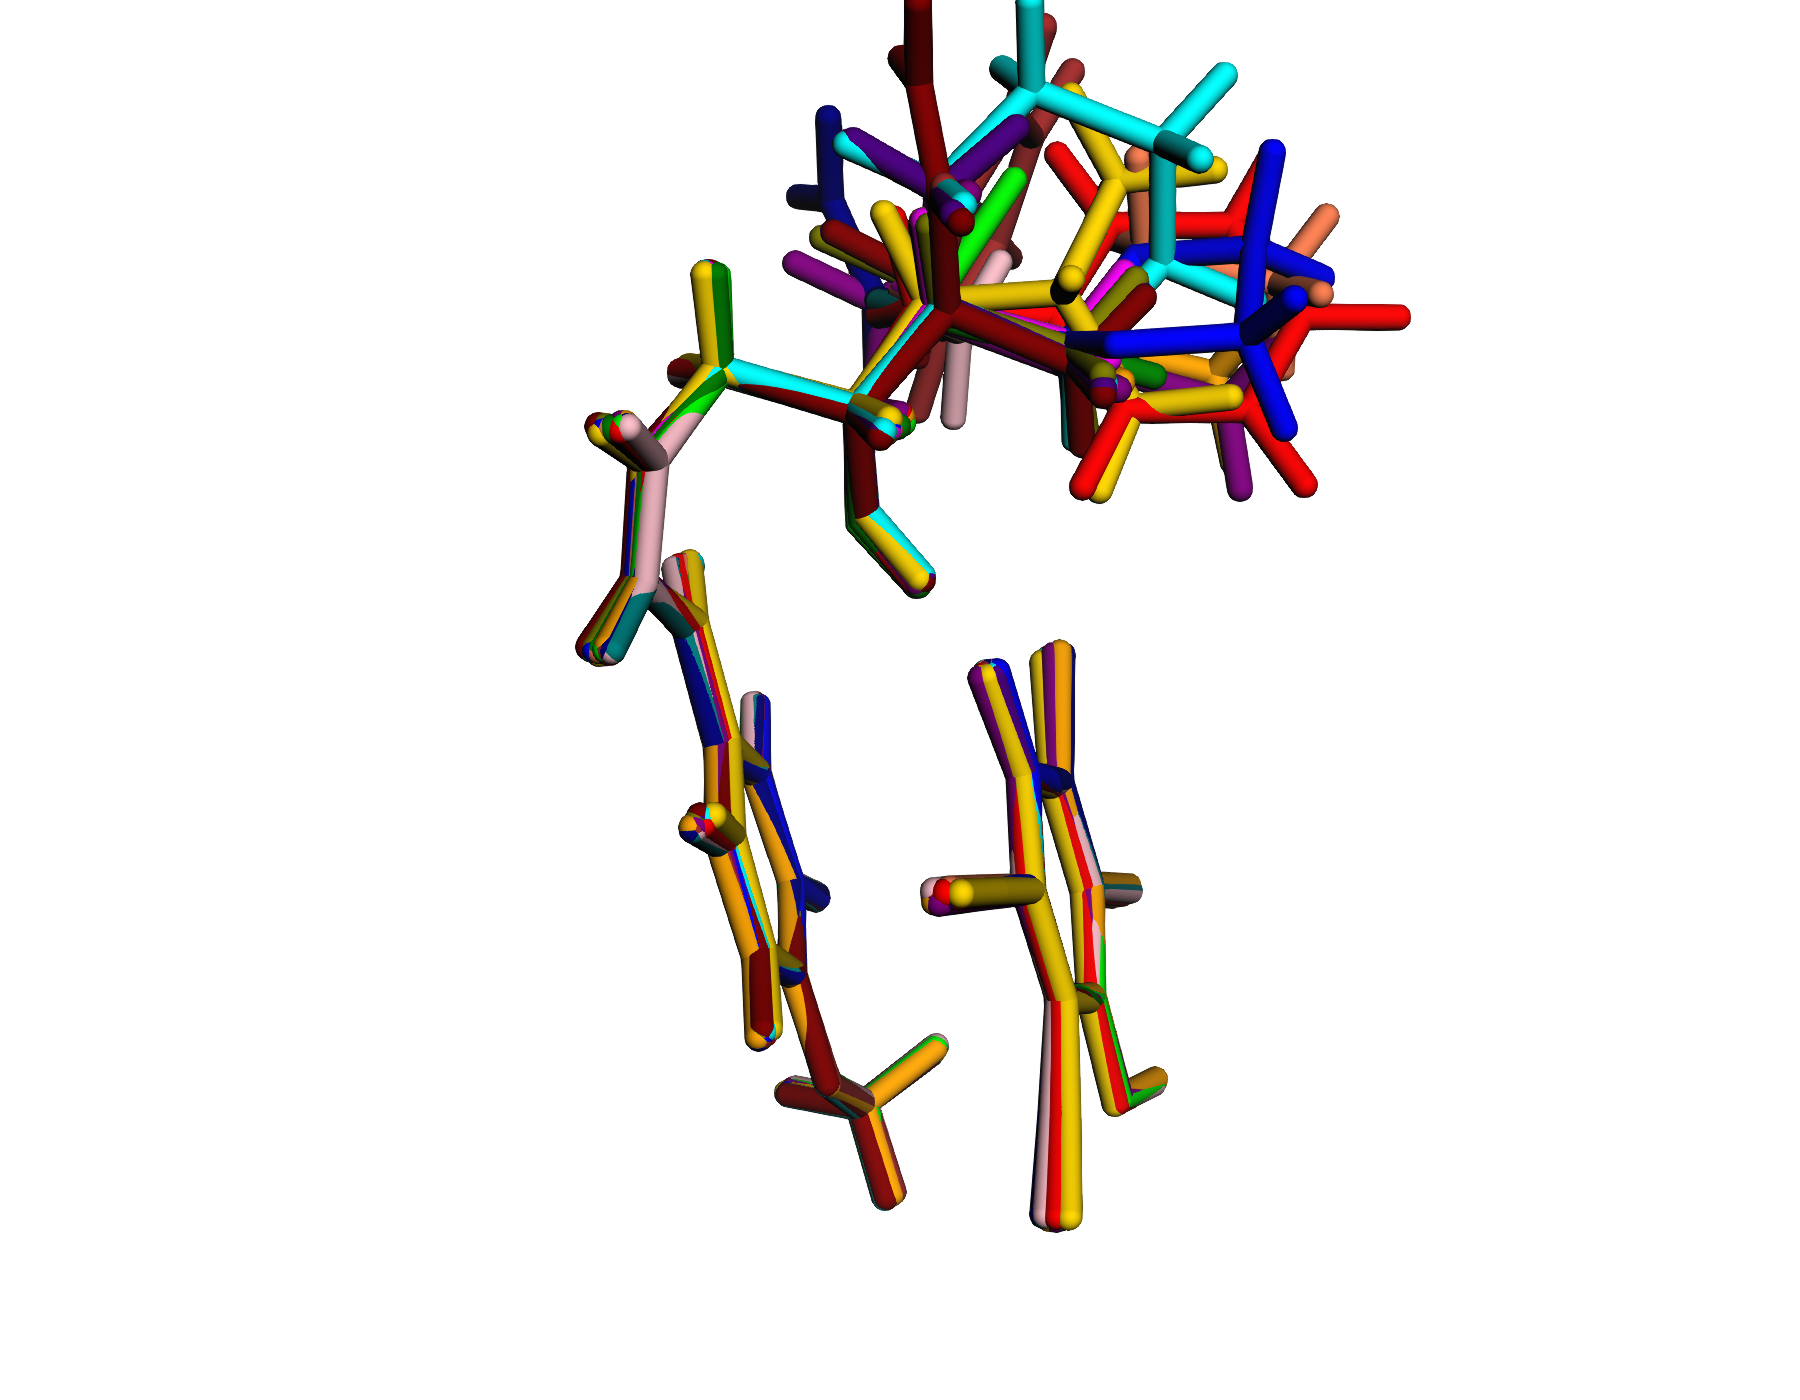

RS_superimposed.png:


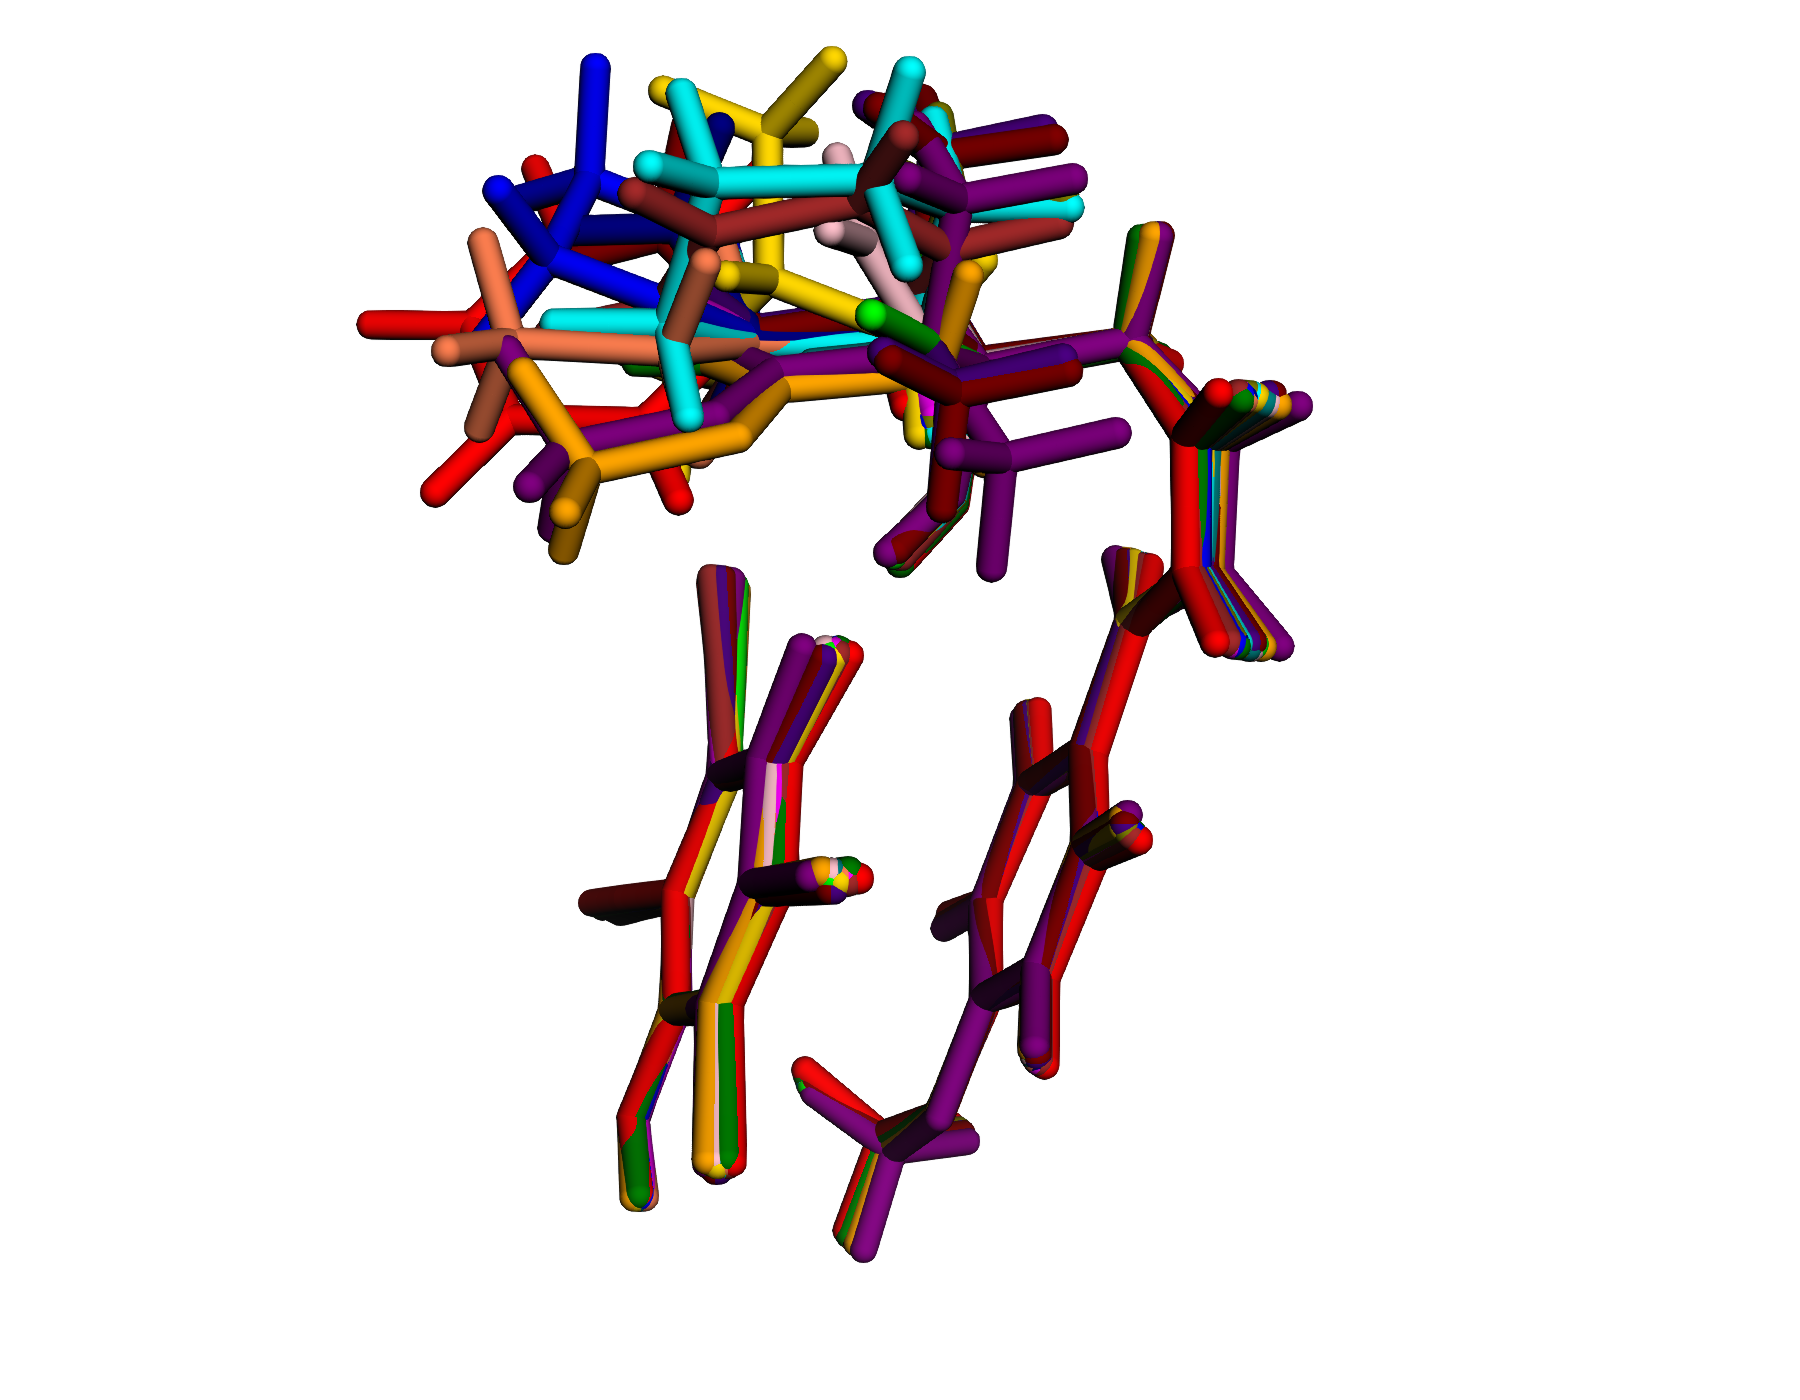

In [13]:
import os

print("Files in:", out_root)
for f in sorted(os.listdir(out_root)):
    full_path = os.path.join(out_root, f)
    size_kb = os.path.getsize(full_path) / 1024
    print(f"  {f:35s} {size_kb:8.1f} KB")

    from IPython.display import Image, display

rr_path = os.path.join(out_root, "RR_superimposed.png")
rs_path = os.path.join(out_root, "RS_superimposed.png")

if os.path.exists(rr_path):
    print("RR_superimposed.png:")
    display(Image(filename=rr_path))
else:
    print("⚠️ RR_superimposed.png not found")

if os.path.exists(rs_path):
    print("RS_superimposed.png:")
    display(Image(filename=rs_path))
else:
    print("⚠️ RS_superimposed.png not found")